# Understanding DBSCAN Galaxy Columns

This tutorial will walk you through the differences between raw galaxies found by DBSCAN, and the galaxies that are reported in the Frontier-E data. 

- Understand DBSCAN
- Investigating stellar masses
- Investigating galaxy radii

<div class="meta-block">
  <div class="meta-row">
    <span class="meta-label">Data</span>
    <span class="chip chip-data">Galaxy Properties</span>
  </div>

  <div class="meta-row">
    <span class="meta-label">Tasks</span>
    <span class="chip chip-task">Query</span>
    <span class="chip chip-task">Select</span>
    <span class="chip chip-task">Filter</span>
  </div>
</div>

In [1]:
import opencosmo as oc
import matplotlib.pyplot as plt
from astropy import units as u

## What is DBSCAN?

If you take a look at the columns contained in a galaxy properties file, you may notice that there are columns labeled with `DBSCAN`. Uncomment the line below and run the cell to see all of the columns in the dataset. Try to find all the columns with this label.

<details>
<summary><b>Tip - Getting a Feel for Your Dataset</b></summary>

If you don't know a lot about what is in a dataset you opened, you can use `.header`, `.columns`, `.descriptions` and more to get a better sense of the dataset. Try replacing the line below with `data.descriptions` to see the difference. See [here](https://opencosmo.readthedocs.io/en/stable/dataset_ref.html#opencosmo.Dataset) for even more ways you can quickly get information on your dataset.

</details> 

In [3]:
data = oc.open('filtered_galaxy_catalog.hdf5')
#data.columns

You should have found 3 different columns:
- `gal_dbscan_mstar`
- `gal_dbscan_radius`
- `gal_dbscan_count`

<details>
<summary><b>Learn More - DBSCAN</b></summary>

In Frontier-E, galaxies are found by running a clustering algorithm, named DBSCAN (Density-Based Spatial Clustering of Applications with Noise), on the star particles of the simulation. However, most columns in the dataset are not computed from the DBSCAN cluster, and are instead calculated based on the star particles that lie within a given aperture centered on the DBSCAN cluster. The process goes something like this:

1. Run DBSCAN on all the star particles to find clusters.
2. Calculate the center of each cluster, taken to be the potential minimum of the star particles
3. Place an aperture around the center of each cluster, 50 kpc was used in this case
4. Compute desired quantities.

</details>

These columns correspond to a specific type of raw galaxy output from the simulation: the properties of clusters of star particles found by DBSCAN. Let's look at those columns again and give them proper definitions:

- `gal_dbscan_mstar`: stellar mass from all star particles contained in the cluster
- `gal_dbscan_radius`: The distance between the center of the cluster and the furthest star particle in the cluster
- `gal_dbscan_count`: Number of star particles contained in the DBSCAN group.

Making visualizations of the difference between DBSCAN and normal aperture galaxies is difficult and rather involved. Instead, lets just plot these columns in suggestive ways that will help us get a sense of how different the DBSCAN clusters are compared to their aperture counterparts.

## Stellar Mass

Let's start with stellar mass. We can grab the DBSCAN mass column, and the aperture mass column (`gal_mass_star`), and plot the ratio. Rather than extracting these columns directly and dealing with the subsequent arrays, OpenCosmo can calculate the ratio for us. We first define the operation we want to do using `.col()` to refer to specific columms (in this case a simple division), and then we feed that operation to `.with_new_columns()` alongside a name for our new column. We will give it a simple but informative name: "mass_ratio".

In [ ]:
#define the operation
ratio = oc.col('gal_dbscan_mstar') / oc.col('gal_mass_star')

#create new column with OpenCosmo
data = data.with_new_columns(mass_ratio = ratio)

With the cell above, OpenCosmo calculated the ratio for us, and now we can simply get the data by using `.select()` and plot.

The lowest value of the DBSCAN/Aperture ratio is  1.0  and the largest is  11.205097198486328


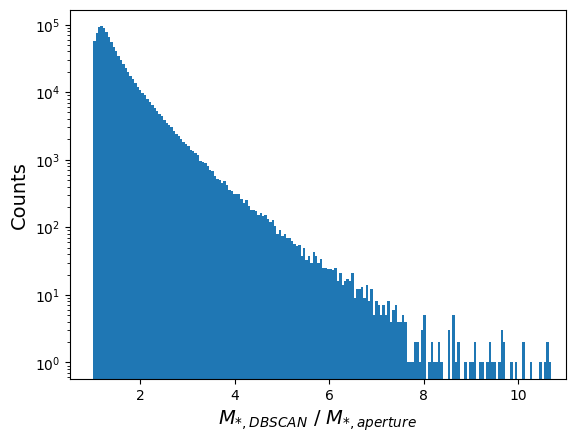

In [ ]:
#extract ratio
ratio = data.select('mass_ratio').get_data()

#print ratio range
print('The lowest value of the DBSCAN/Aperture ratio is ', ratio.min(),' and the largest is ', ratio.max())

#plot
plt.hist(ratio, bins = 200)
plt.xlabel('$M_{*,DBSCAN}$ / $M_{*,aperture}$', fontsize = 14)
plt.ylabel('Counts', fontsize = 14)
plt.yscale('log')
plt.xlim(0.5, 11)
plt.show()

A ratio of 1 means that every particle in the DBSCAN cluster is contained within the aperture. It's a good sign that most galaxies lie at or around a ratio of 1, implying that the aperture galaxy represents the DBSCAN cluster well. However, we also see ratios can get as large as 11, with hundreds of galaxies at a ratio of 4 or higher. 

<details>
<summary><b>Question: What causes such large mass discrepancies? What types of galaxies are more likely to have larger DBSCAN masses?</b></summary>

One reason for these large mass ratios is **Overlinking**, where the DBSCAN algorithm links together multiple galaxies that should be identified separately. This can happen during an active merger, where the boundaries of the two galaxies can get blurred, but it can also happen for massive central galaxies in galaxy clusters. In massive clusters, the Intra-Cluster Light (ICL) can act as a bridge that links multiple galaxies together if it is dense enough.

</details>

One might expect the ratio to be higher for more massive galaxies. To show this, we can look at the mass ratio as a function of galaxy mass. To break the dataset into mass bins we will have to use `.filter()`. First, you have to define a filtering criterion, using `.col()` to refer to specific columns, then pass it to OpenCosmo. 

> **Tip:** Always Filter First
>
>It is important to filter before selecting a column because `.select()` will get rid of every column we don't explicitly ask for, even the one we are trying to filter on! Try swapping the two below and see the error you get.

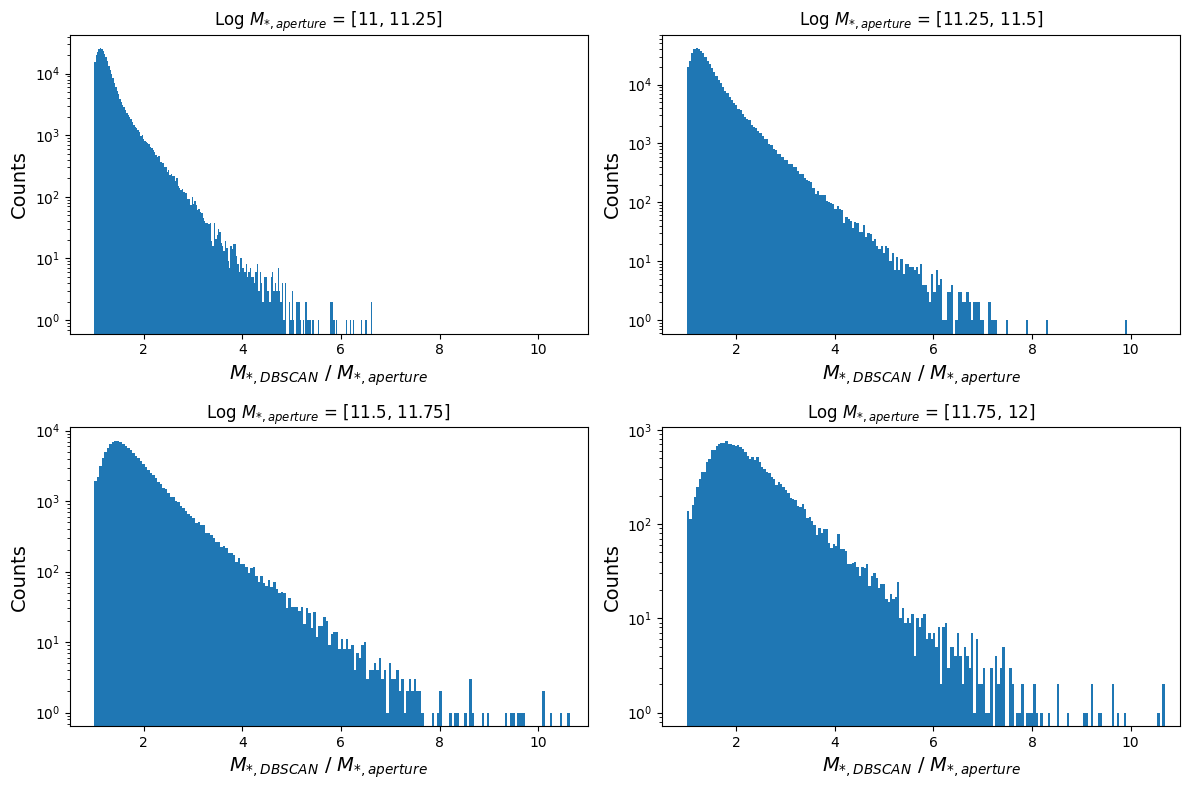

In [ ]:
#define our log bin edges and figure
bins = [11, 11.25, 11.5, 11.75, 12]
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

#filter for each axis
for ind, ax in enumerate(axs.flatten()):
    
    #define mass bin filter criterion
    mask = (oc.col('gal_mass_star') < 10**bins[ind+1]) & (oc.col('gal_mass_star') > 10**bins[ind])
    
    #filter and select the mass ratio
    ratio = data.filter(mask).select('mass_ratio').get_data()
    
    #plot
    ax.hist(ratio, bins = 200)
    ax.set_xlabel('$M_{*,DBSCAN}$ / $M_{*,aperture}$', fontsize = 14)
    ax.set_ylabel('Counts', fontsize = 14)
    ax.set_title('Log $M_{*,aperture}$ = ' + f'[{bins[ind]}, {bins[ind+1]}]')
    ax.set_yscale('log')
    ax.set_xlim(0.5, 11)

plt.tight_layout()
plt.show()

Notice how both the peak and tail of the distribution shifts towards larger mass ratios, thus showing that mass discrepancies get worse at larger masses!

## Galaxy Radius

Let's see if we get similar results by comparing the radius of the DBSCAN cluster to the aperture, which was 50 kpc for this simulation. The process is the same as above, but this time, when we make our new column, we will divide by the aperture.

The lowest value of the DBSCAN/Aperture ratio is  0.7453400641679764  and the largest is  47.50483512878418


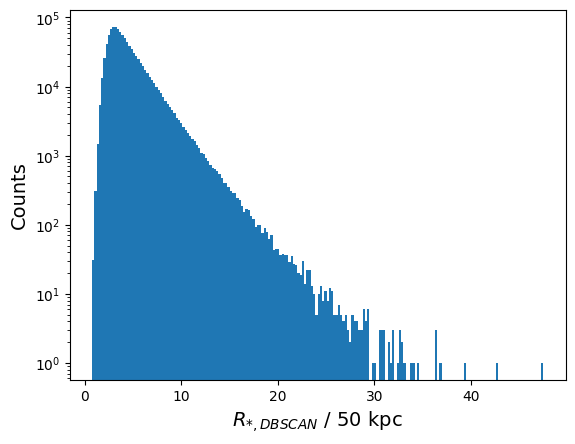

In [ ]:
#make new column
ratio = oc.col('gal_dbscan_radius') / (0.05*u.Mpc)
data = data.with_new_columns(radius_ratio = ratio)

#extract column data
ratio = data.select('radius_ratio').get_data()

#print ratio range
print('The lowest value of the DBSCAN/Aperture ratio is ', ratio.min(),' and the largest is ', ratio.max())

#plot
plt.hist(ratio, bins = 200)
plt.xlabel('$R_{*,DBSCAN}$ / 50 kpc', fontsize = 14)
plt.ylabel('Counts', fontsize = 14)
plt.yscale('log')
plt.show()

We get a similar result as above! Ratio values below 1 repesent DBSCAN clusters that are fully contained within their aperture, and ratios greater than 1 mean that the cluster extends past the aperture. As before, let's also look at this plot in different mass bins.

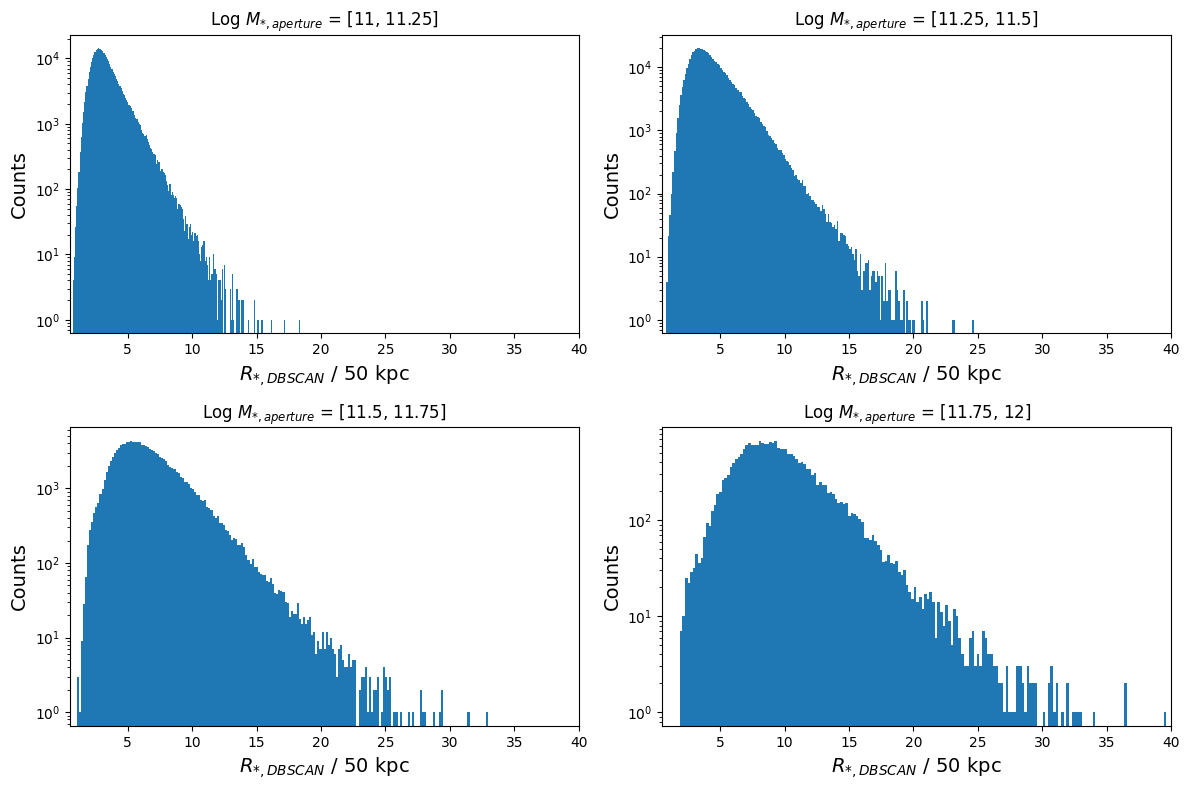

In [ ]:
bins = [11, 11.25, 11.5, 11.75, 12]
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ind, ax in enumerate(axs.flatten()):
    
    #filter and get ratio
    mask = (oc.col('gal_mass_star') < 10**bins[ind+1]) & (oc.col('gal_mass_star') > 10**bins[ind])
    ratio = data.filter(mask).select('radius_ratio').get_data()
    
    ax.hist(ratio, bins = 200)
    ax.set_xlabel('$R_{*,DBSCAN}$ / 50 kpc', fontsize = 14)
    ax.set_ylabel('Counts', fontsize = 14)
    ax.set_title('Log $M_{*,aperture}$ = ' + f'[{bins[ind]}, {bins[ind+1]}]')
    ax.set_yscale('log')
    ax.set_xlim(0.5, 40)

plt.tight_layout()
plt.show()

Just like for the mass ratio, the peak and tail shift to higher values as we increase mass. This is also clear evidence of overlinking because the extent of your cluster will be significantly more than a 50 kpc aperture if it contains multiple linked galaxies.

<details>
<summary><b>It's Your Turn - What About `gal_dbscan_count`?</b></summary>

Given that the mass of each galaxy comes from summing the mass of its star particles, we will get very similar results if we look at the ratio of particle count. To see if you fully understand this tutorial, make similar plots to the above using this column. You can estimate the number of star particles in the aperture by dividing the total galaxy stellar mass by the median star particle mass. For Frontier-E the median star particle mass is $\sim 2.25 \times 10^{8} M_\odot$

</details>

The takeaway here is that one should be careful when using the properties of very massive galaxies, as particle overlinking may influence the reported mass and size of the galaxy. For most use cases, the effects of overlinking is small and can be ignored, but for more complex analyses it should be taken into account.